<a href="https://colab.research.google.com/github/Vanshu2374/ML-projects/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Bike Price Prediction Project

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13648 entries, 0 to 13647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   13648 non-null  object 
 1   price       13648 non-null  float64
 2   city        13648 non-null  object 
 3   kms_driven  13648 non-null  float64
 4   owner       13648 non-null  object 
 5   age         13648 non-null  float64
 6   power       13648 non-null  float64
 7   brand       13647 non-null  object 
dtypes: float64(4), object(4)
memory usage: 853.1+ KB
maximum price of ktm bike :- 860000.0
Total no. of unique bike of hero :- 74
Total no. of cd delux unique bik :- 200
minimum price of cd delux bike :- 10000.0


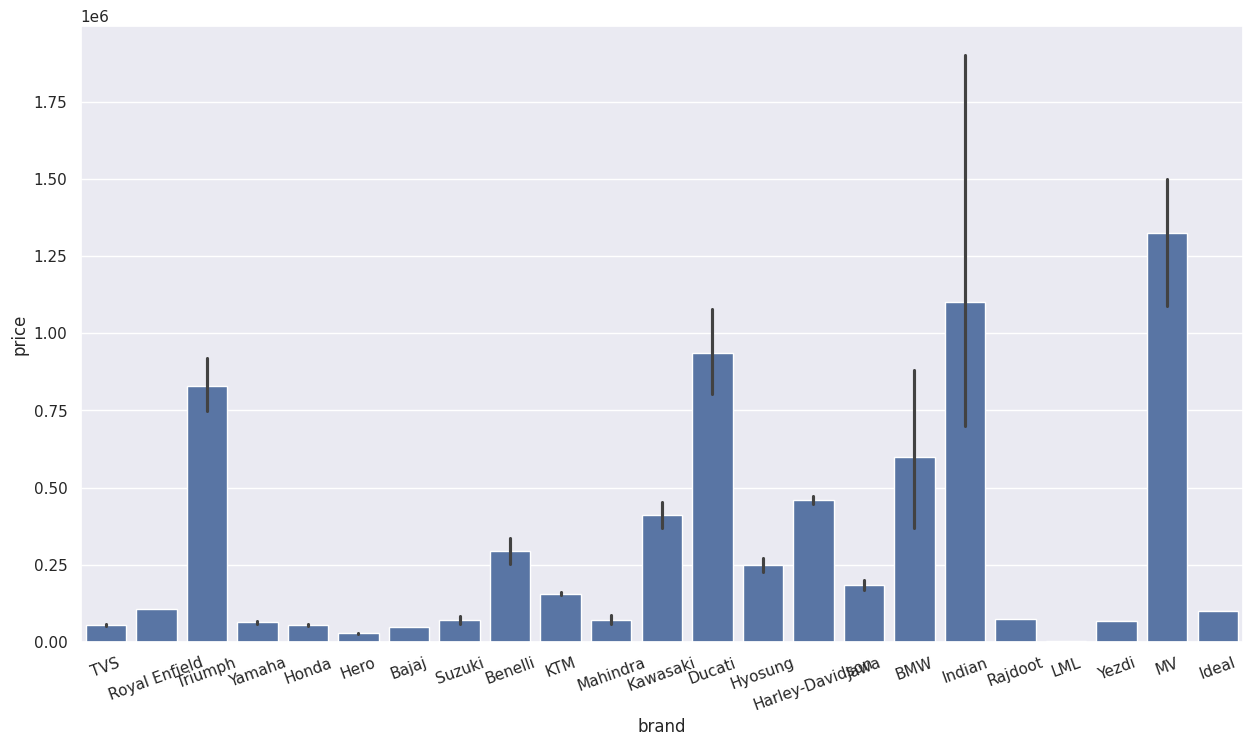

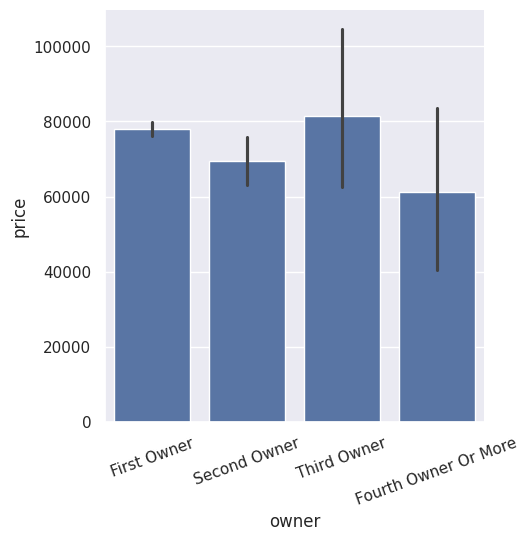

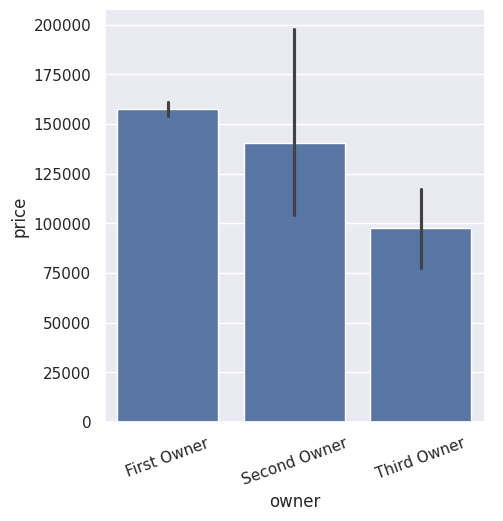

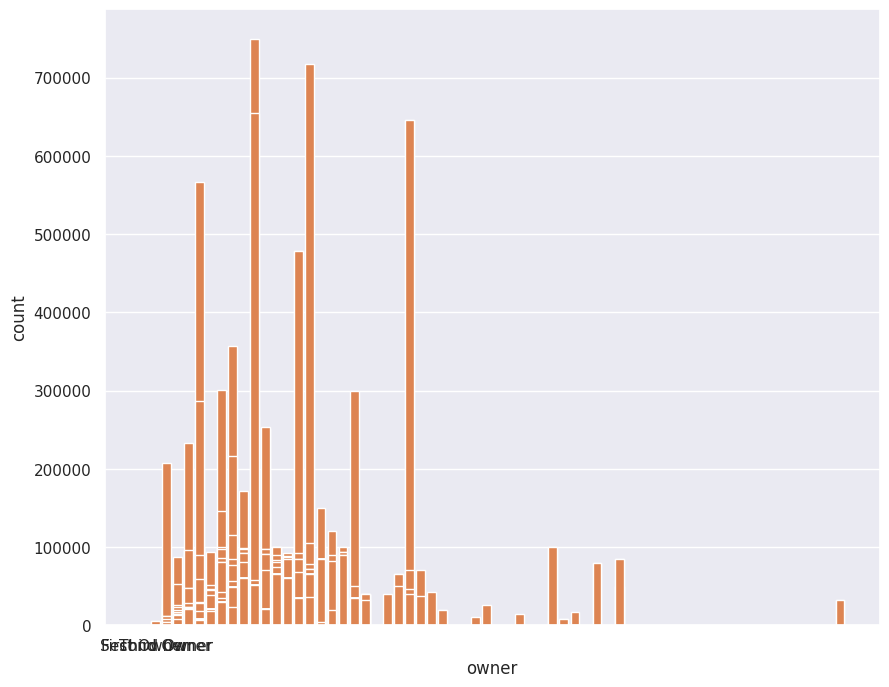

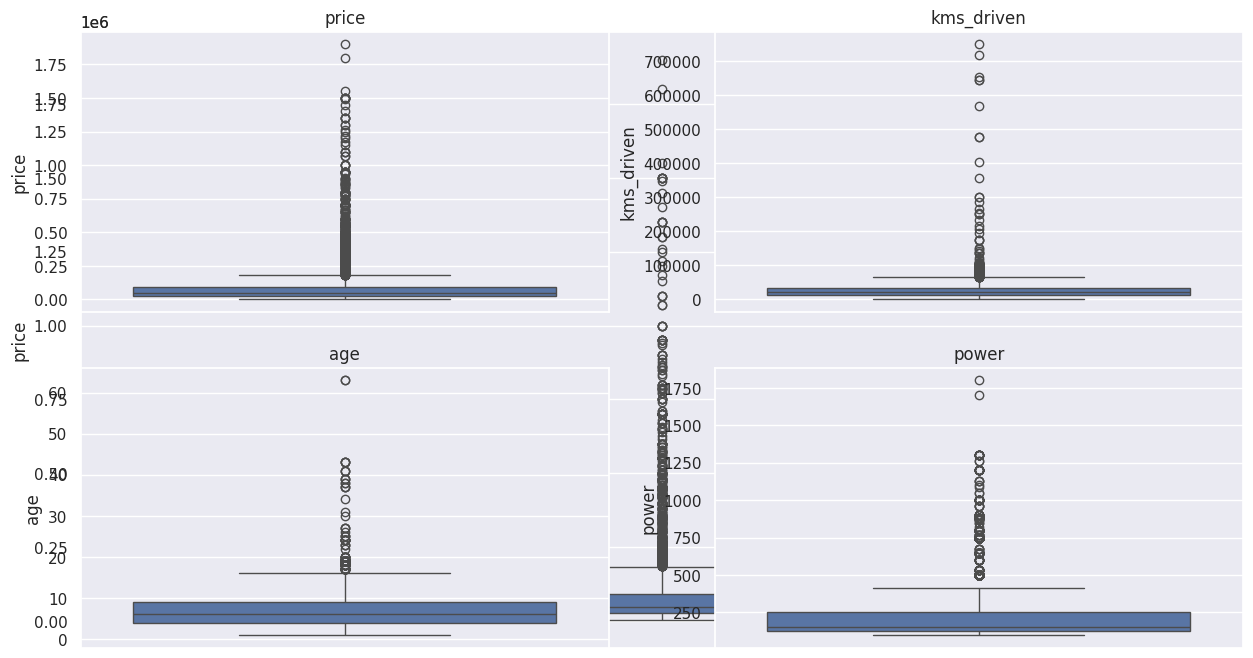

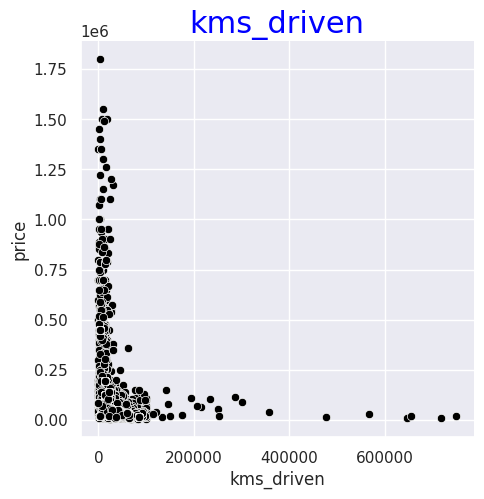

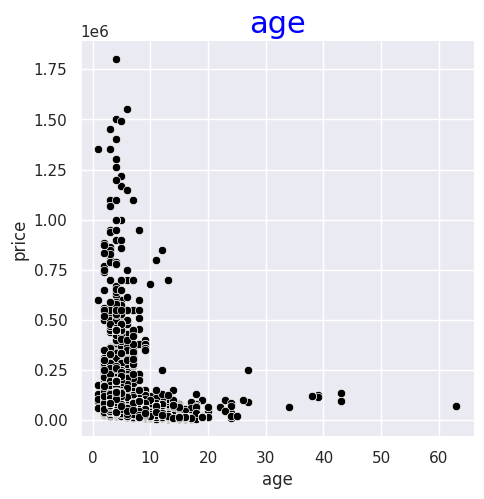

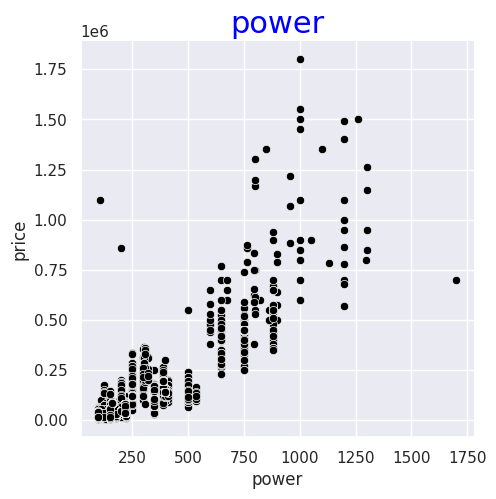

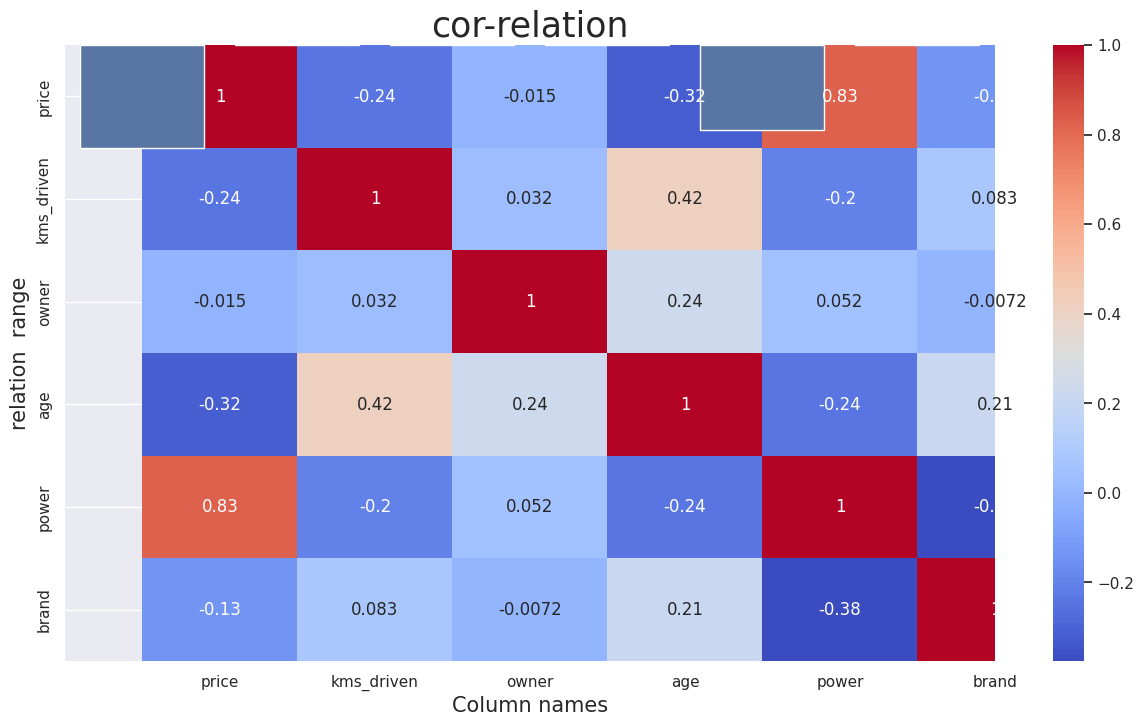

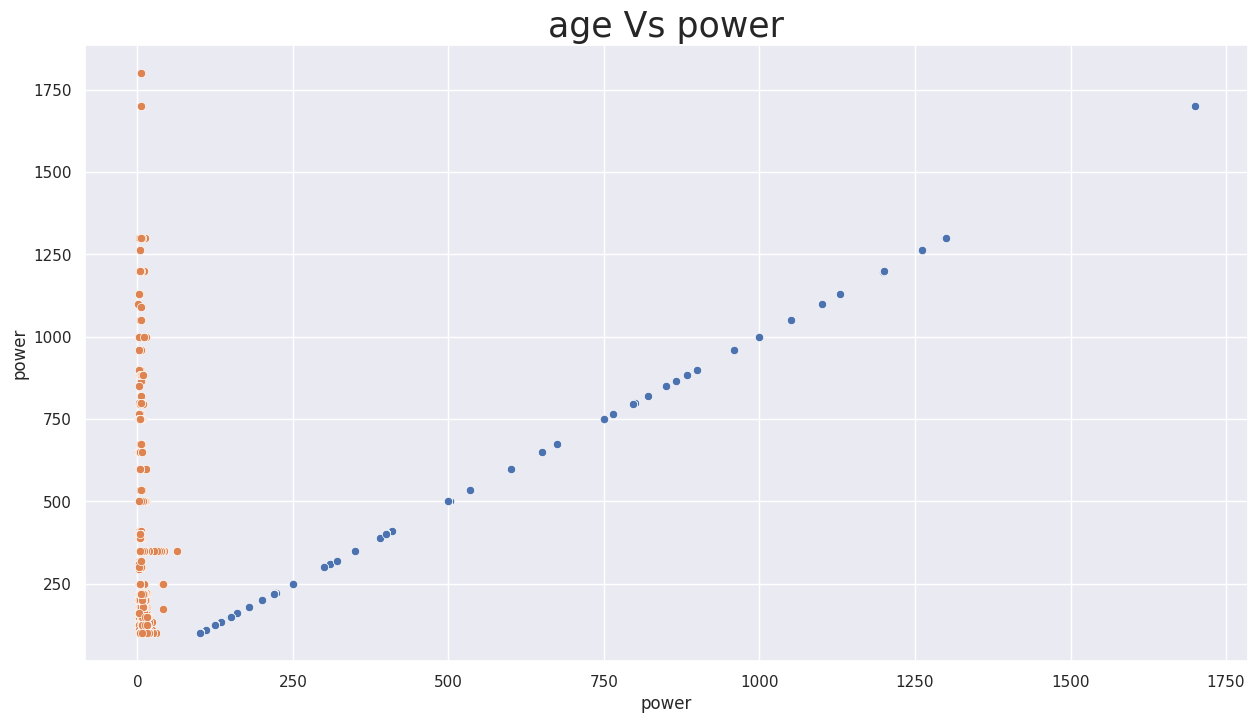

(12678, 7)
(8184, 7)
Training accuracy :-  0.9849691031516078
Testing accuracy :-  0.934706130123796
Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END max_depth=3, max_features=auto, min_samples_leaf=10, min_samples_split=20, n_estimators=427; total time=   0.0s
[CV] END max_depth=3, max_features=auto, min_samples_leaf=10, min_samples_split=20, n_estimators=427; total time=   0.0s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=463; total time=   1.5s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=10, min_samples_split=50, n_estimators=463; total time=   0.9s
[CV] END max_depth=4, max_features=auto, min_samples_leaf=15, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END max_depth=4, max_features=auto, min_samples_leaf=15, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=354; total time

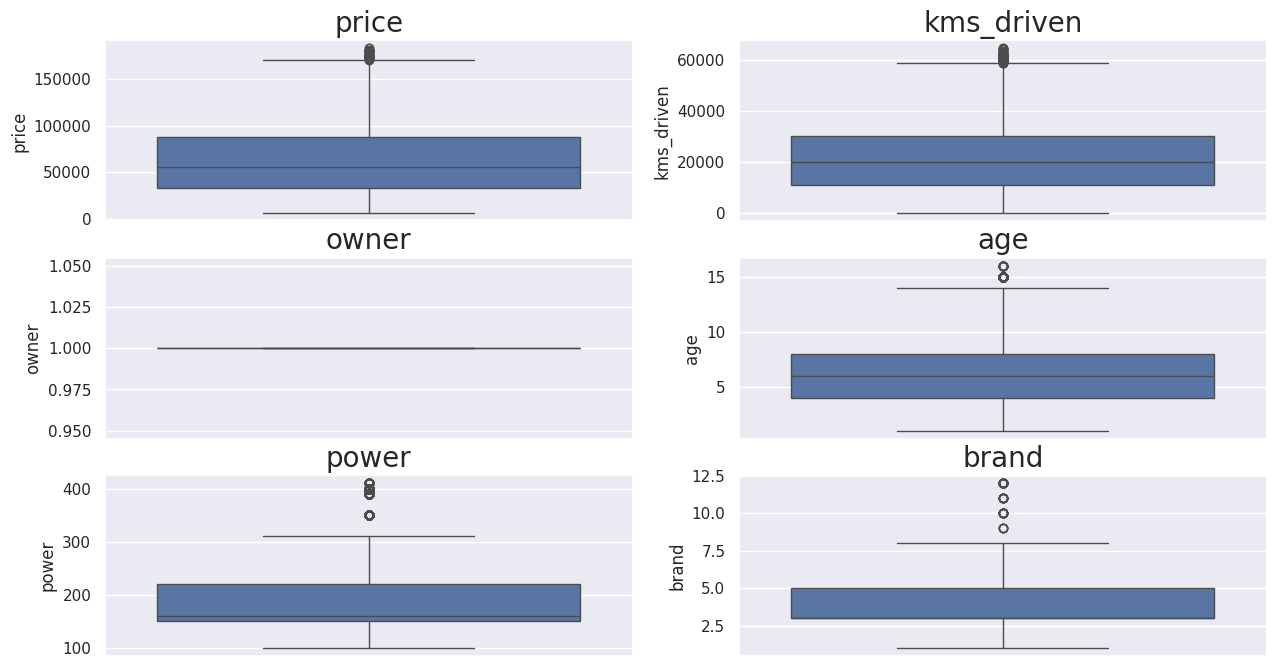

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import pickle
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Used_Bikes.csv')
df.head()
df.shape
df.info()
df.describe()
df['brand'].value_counts()
df['owner'].value_counts()
### check the missing value
df.isnull().sum().sum()       # there is no missing value
df['brand'].nunique()         # total 23 brand
df['brand'].unique()
# all are unique brands available in my dataset
df['bike_name'].nunique()
# Total no. unique bikes available in my dataset
df[df['brand']=='Hero'].shape
# total Hero brand bike
## KTM bike analyses
ktm = df[df['brand']=='KTM']
ktm.head()
ktm.shape[0]          # total KTM bike
ktm['bike_name'].nunique()    # 10 unique KTM bikes
ktm['bike_name'].unique()
# all are ktm bike available in our dataset
print(f"maximum price of ktm bike :- {ktm['price'].max()}")
ktm['owner'].value_counts()
# availibility of ktm bike
# cd delux bike analysis
hero = df[df['brand']=='Hero']
hero.head()
print(f"Total no. of unique bike of hero :- {hero['bike_name'].nunique()}")
cd_delux = hero[hero['bike_name'].str.contains('CD')]
cd_delux.head()
#filtering data of cd delux bike of hero
print(f"Total no. of cd delux unique bik :- {cd_delux.shape[0]}" )          # 706 CD delux bike
print(f"minimum price of cd delux bike :- {cd_delux['price'].min()}")      # minimum price of cd delux bike
hero[hero['bike_name'].str.contains('CD')]['price'].max()         # maximum price of CD Delux
df['city'].value_counts().keys().shape[0]          # 443 city record available
### analyse the data with groupby properties
df.head(2)
grouped=df.groupby(by='city')       # grouped the data by city columns
grouped.get_group('Ahmedabad')
f"bikes available in Delhi :- {grouped.get_group('Delhi').shape[0]}"
grouped.get_group('Delhi')[['age']].head()       # get a particular column from the grouped data
grouped.get_group('Delhi')[['age']].max()        #maximum old bike in delhi
grouped.get_group('Delhi')[['age']].min()        #minimum old bike in delhi
df[(df['city']=='Delhi') & (df['age']==1)]         #[['bike_name','brand']]
grouped.get_group('Delhi')['brand'].value_counts().keys()         # all brand available in Delhi
grouped['owner'].value_counts()['Delhi']           # mostly first handed used bikes availabel in delhi
## divide the data based on the data types
df.dtypes
### Dividing Data  into 2 parts based on data type
catigorical_data = df.select_dtypes(include='O')
catigorical_data.head()
numerical_data = df.select_dtypes(exclude='O')
numerical_data.head()
numerical_data.describe()
catigorical_data.describe()
# to remove the "bike_name" feature
df=df.drop('bike_name',axis=1)
df.head(2)
## Data Visualization
sns.set(rc={'figure.figsize':(15,8)})
sns.barplot(x=df['brand'],y=df['price'])
plt.xticks(rotation=20)
plt.show()
sns.catplot(x='owner',y='price',kind='bar',data=df)
plt.xticks(rotation=20)
plt.show()
sns.catplot(x='owner',y='price',kind='bar',data=ktm)   # for ktm bike
plt.xticks(rotation=20)
plt.show()
plt.figure(figsize=(10,8))
sns.countplot(x='owner',data=df.query("brand=='KTM'"))
# sns.set(rc={'figure.figsize':(18,10)})
plt.bar(x=df['age'],height=df['kms_driven'])
plt.show()
df[(df['age']>=44)&(df['age']<=60)]      # there is no record in between this range
numerical_data.columns
sns.boxplot(df['price'])
for i , colum in enumerate(numerical_data.columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(df[colum])
    plt.title(colum)

## data cleaning
df.dtypes
df['age']=df['age'].astype(int)
dic={'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth Owner Or More':4}

df['owner']=df['owner'].map(dic)
df['owner'].value_counts()
ser=df['city'].value_counts()
ser[ser>10].keys()
city_name=['Delhi', 'Bangalore', 'Mumbai', 'Hyderabad', 'Pune', 'Chennai',
       'Lucknow', 'Jaipur', 'Ghaziabad', 'Ahmedabad', 'Noida', 'Bhopal',
       'Gautam Buddha Nagar', 'Kanchipuram', 'Jodhpur', 'Karnal', 'Allahabad',
       'Rupnagar', 'Gurgaon', 'Godhara', 'Faridabad', 'Perumbavoor', 'Kadapa',
       'Ludhiana', 'Kolkata', 'Thane', 'Jhansi', 'Vadodara', 'Surat',
       'Jalandhar', 'Chandigarh', 'Rajkot', 'Indore', 'Dehradun', 'Patna',
       'Navi Mumbai', 'Nagpur', 'Coimbatore', 'Guwahati', 'Tiruvallur',
       'Bhubaneshwar', 'Howrah', 'Kanpur', 'Aurangabad', 'Cuttack',
       'Visakhapatnam', 'Alibag', 'Alipore', 'Nashik', 'Ranchi', 'Kalyan',
       'Rohtak', 'Udaipur', 'Gorakhpur', 'Agra', 'Kota', '24 Pargana',
       'Meerut', 'Gandhinagar', 'Ernakulam']
maxc_ten_bike = df[df['city'].isin(city_name)]
maxc_ten_bike.head()
# these are all city data that having at least 10 bikes
maxc_ten_bike['city'].value_counts().shape[0]              # total 60 city available in my data
# Filtering Data ...
bikes_name=df['brand'].value_counts()
most_available_bikes = bikes_name[bikes_name>10].keys()
greater_than_ten_bike = maxc_ten_bike[maxc_ten_bike['brand'].isin(most_available_bikes)]
greater_than_ten_bike.head()

# bike brand labeling
bike_encoding_dict={'Bajaj':3, 'Hero':16, 'Royal Enfield':1, 'Yamaha':5, 'Honda':6, 'Suzuki':7, 'TVS':8,
       'KTM':2, 'Harley-Davidson':4, 'Kawasaki':9, 'Hyosung':10, 'Benelli':11, 'Mahindra':12,
       'Triumph':13, 'Ducati':14, 'BMW':15}
greater_than_ten_bike['brand']=greater_than_ten_bike['brand'].map(bike_encoding_dict)
greater_than_ten_bike.head()
df2 = greater_than_ten_bike
df2[df2['brand']==12].head()
# TO check the correlation in between independent and dependent feature
sns.relplot(x='kms_driven',y='price',data=df2,color='black')            #,hue='age',
plt.title('kms_driven',fontdict={'fontsize':22,'color':'blue'})
plt.show()
sns.relplot(x='age',y='price',data=df2,color='black')
plt.title('age',fontdict={'fontsize':22,'color':'blue'})
plt.show()
# positive relation
sns.relplot(x='power',y='price',data=df2,color='black')            #,hue='age',
plt.title('power',fontdict={'fontsize':22,'color':'blue'})
plt.show()
sns.heatmap(df2.select_dtypes(exclude='O').corr(),annot=True,cmap='coolwarm')
# checking corelation
sns.barplot(x = df2.select_dtypes(exclude='O').corr()['price'].keys(),y=df2.select_dtypes(exclude='O').corr()['price'].values)
plt.title('cor-relation',size=25)
plt.xlabel('Column names',size=15)
plt.ylabel('relation  range',size=15)
plt.show()
# ploting the corelation
sns.scatterplot(x='power',y='power',data=df2)
# this is +1 relationship because, we plot relation in same columns
sns.scatterplot(x='age',y='power',data=df)
plt.title('age Vs power',size=25)
plt.show()
## to remove the outliers by IQR method
numerical_data = df2.select_dtypes(exclude='O')
categorical_data = df2.select_dtypes(include='O')

#Where:<br>
#Q1 is the 25th percentile,<br>
#Q3 is the 75th percentile,<br>
#IQR is the interquartile range
#( Q3−Q1 ), and 1.5 <br>
#1.5 is the multiplier that determines how far away from the quartiles the <br>bounds will be.
### formula to remove outliers from the dataset
#LL= Q1 - (1.5 * IQR)<br>
#UL= Q3 + (1.5 * IQR)<br>

# from kms_driven feature
lower_limit = dict()
uper_limit = dict()

for colum in numerical_data.columns:
    q1,q3=df2[colum].quantile([.25,.75])   # 1st and 3rd quartile
    IQR=q3-q1        # calculating interquatile range
    LL=q1-(1.5*IQR)    # lower range
    UL=q3+(1.5*IQR)
    lower_limit[colum]=LL
    uper_limit[colum]=UL

lower_limit
# lower limits for all columns
uper_limit
# upper limits for all columns
print(df2.shape)
temp = 0
for lower_upper_pairs in list(zip(uper_limit.items(),lower_limit.items())):
    df2 =   df2[(df2[lower_upper_pairs[0][0]] >= lower_upper_pairs[1][1])  & (df2[lower_upper_pairs[0][0]] <= lower_upper_pairs[0][1])]
print(df2.shape)
df2.head(2)
df2 = df2.drop('city',axis=1)
df2.head(2)
for plot_no , col in enumerate(df2.columns):
    plt.subplot(3,2,plot_no+1)
    sns.boxplot(df2[col])
    plt.title(col,size=20)

## Set the variable for ML model
x = df2.drop('price',axis=1)
y = df2[['price']]
x.head(2)
y.head(2)
# Splitting the data into train and test
from sklearn.model_selection import train_test_split
x_train  ,x_test,   y_train,  y_test =  train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,  x_test.shape,   y_train.shape,   y_test.shape
x_train
y_train
from sklearn.ensemble import  RandomForestRegressor
rdf = RandomForestRegressor()
rdf.fit(x_train,y_train)
print("Training accuracy :- ",rdf.score(x_train,y_train))
print("Testing accuracy :- ",rdf.score(x_test,y_test))

# HYPER PARAMETER TUNING
#This is for research purpose, because yet now we got it good accuracy
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
rdf2 = RandomForestRegressor()
# Defining Parameters
n_estimators = [int(x) for x in np.linspace(start=100,stop=500,num=12)]
max_features = ['auto','sqrt']
max_depth = [int(x) for x in np.linspace(start=5,stop=3,num=6)]
min_samples_split = [20,30,50]
min_samples_leaf = [15,10,20]
# param grid
random_grid={'n_estimators':n_estimators,
            'max_features':max_features,
            'max_depth':max_depth,
            'min_samples_split':min_samples_split,
            'min_samples_leaf':min_samples_leaf}
rdm_rand_forest = RandomizedSearchCV(estimator=rdf2,param_distributions=random_grid,n_iter=10,cv=2,verbose=2,scoring='neg_mean_squared_error')
rdm_rand_forest.fit(x_train,y_train)
rdm_rand_forest.best_params_
best_estimator = rdm_rand_forest.best_estimator_
print("Training accuracy :- ",best_estimator.score(x_train,y_train))
print("Testing accuracy :- ",best_estimator.score(x_test,y_test))
# now THe accuracy is decreased 💔 our previos model is good
### Save th3 model
import joblib
joblib.dump(rdf,'updated_model.lb')
loaded_model = joblib.load('updated_model.lb')
### Prediction
pred = rdf.predict(x_test)
compare = y_test
compare['prediction'] = pred
compare.columns = ['actual','prediction']
compare.iloc[0:20]
print(rdf.score(x_train,y_train))
print(rdf.score(x_test,y_test['actual']))

#THANK YOU